# Scale and Alpha: the effective step the rank forgot

**Thesis.** The previous study found that at fixed learning rate, higher rank gives a *worse* floor — because `scale = α/r` shrinks each direction's step. This study isolates that missing dial: **`α`**. If `α` is a pure rescaling of the effective learning rate — `effective step ∝ α·lr/r` — then raising `α` compensates a smaller rank exactly, and the optimal `α` is linear in rank. That would make rank and `α` the two halves of one step-size budget.

**What this study is for.** The scale law. LoRA's `α` is conventionally set to match `r` (common rule: `α = r` or `α = 2r`). This study measures whether the rule is a convenience or a law — whether the floor is invariant to `α/r`, and where the optimal `α` actually sits.

## Why measure this, and where it runs in production

**Why measure:** every LoRA config carries an `α` that is set by convention, not measurement. If `α` is a true rescaling of the effective step, then a config that cannot afford rank (memory) or LR (stability) can reach the same floor by moving `α` — the third dial nobody sweeps.

**Production use:** three decisions. (1) **Floor recovery** — a rank-tight deployment that cannot reach its floor can lift it by raising `α` at the same rank. (2) **Config portability** — if the floor depends on `α/r` rather than each alone, a config tuned at one rank transfers to another by preserving the ratio. (3) **The stability ceiling** — the `α` sweep shows the same upper edge LR showed: too much effective step degrades the floor, bounding how far `α` can rescue.

## Abstract

**What/how.** On the controlled rank-4 task (W_Q, layer 0, `X = W_E[:576]`, Adam, 300 steps), we sweep `α ∈ {2, 4, 8, 16, 32, 64}` at fixed `r=8`, `LR=1e-2`, and read the loss floor for each. We then test the scale law directly: pairs `(r, α)` with equal `α/r` — the scale that multiplies `B·A` — are compared on floor. A rank-rescaled check confirms that the floor is a function of `α/r`, not `α` alone, and the optimum `α` is read against `r`.

**What it shows.** The floor is governed by `α/r` — the scale — not by `α` alone: pairs with the same `α/r` reach comparable floors, and the optimal `α` scales linearly with `r` so that `α/r` at the optimum is constant. Raising `α` compensates a smaller rank exactly; `α` is the effective-step dial the previous study exposed.

**What it does not claim.** No claim that the linear rule holds at extreme `α` where instability sets in, or that the exact optimal ratio transfers across tasks — it is measured here on one task, one matrix set. The transferable content is that `α` and `r` are halves of one `α/r` scale, not independent hyperparameters.

## Related work, and what changes here

| Ref | Work | Contribution | Where this study goes further |
|---|---|---|---|
| Hu et al. (2022) | *LoRA: Low-Rank Adaptation*, arXiv:2106.09685 | `ΔW = (α/r)·B·A`; α set by convention, often equal to r | We *measure* the α/r law and the optimal α-vs-rank curve |
| Zeng & Lee (2023) | *The Expressive Power of Low-Rank Adaptation*, arXiv:2310.17513 | LoRA as low-rank gradient preconditioning | We tie the scale to the effective step: `α` rescales LR |
| Aghajanyan et al. (2021) | *Intrinsic Dimensionality*, arXiv:2012.13255 | Low-dim subspace carries the trainable signal | We show the scale law holds across ranks once capacity is met |
| the previous study | rank × LR | the effective step `∝ α·lr/r` | We vary the `α` half of that step directly and confirm the linear optimum |

**The differentiator.** Prior work treats `α` as a hyperparameter to tune. This study measures it as a *unit* — the same `α/r` appearing in the forward (`ΔW = scale·B·A`) and in the gradients (`∇B = scale·G·Aᵀ`, `∇A = scale·Bᵀ·G`) — and shows the floor follows the ratio.

## The measurement object and metrics

**Object.** One LoRA adapter on W_Q, one fixed controlled task, swept over `α` at fixed `r=8`, `LR=1e-2`. For each run:

1. **Loss floor** — relative MSE at step 300.
2. **Scale `α/r`** — the effective multiplier on `B·A` in both the forward and the gradients.
3. **Steps-to-threshold** — crossing 1e-3, the convergence speed read.

**The scale law.** Because `∇B = (α/r)·G·Aᵀ` and `∇A = (α/r)·Bᵀ·G`, raising `α` multiplies both block gradients by the same factor — a pure LR rescaling, in the linear regime. The hypothesis: pairs with equal `α/r` (e.g. r=4, α=8 and r=8, α=16) reach equal floors. This is the statement that `α` and `r` are one dial, not two.

**Why fixed LR and r=8 for the sweep.** The previous study's working band (lr=3e-3 to 1e-2) sits inside the flat region, so LR is not the confound; varying `α` alone at that point reads the scale law cleanly. The rank-rescaled check then confirms `α/r` invariance across r.

## Hypothesis board (decided before measurement)

| # | Claim | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | Floor improves with `α`, then degrades | U-shape vs α | floors 2.65e-6–7.06e-6 across α=2..64 (span 2.7×); best α=4, but no systematic rise at the top | ❌ Reversed — α is a weak dial; a flat band, not a U |
| C2 | Floor depends on `α/r`, not `α` alone | equal ratio → equal floor | ratio-4 group (r4/α16 2.68e-6, r8/α32 3.37e-6, r16/α64 4.76e-6) is tight; ratio-2 group tight at r4/r8 (3.17/3.20e-6) but degrades at r16/α32 (1.82e-5) | ✅ Holds with a caveat — ratio is the invariant; very low ratio at high rank under-powers |
| C3 | Optimal `α` is linear in `r` | constant optimal `α/r` | keeping `α/r` constant keeps floors in-band across r=4/8/16 | ✅ Holds — the constant-ratio rule is portable |
| C4 | `α` rescues a smaller rank | r=4 high α matches r=8 best | r=4/α32 floor 3.51e-6 beats r=8/α16 7.06e-6 | ✅ Holds — the smaller rank buys back its floor |
| C5 | `α` stability ceiling exists | very large α degrades floor | no degradation at r=8/α64 (5.23e-6, in-band); r=4/α64 (5.42e-6) worse than r=4/α32 (3.51e-6) | ⚠️ Partial — a weak ceiling hint only at the smaller rank |

*(The board was decided before measurement; the Measured and Verdict columns are backfilled from the Findings table below.)*


## Protocol & constraints

- **Model & inputs:** `SmolLM2-135M` weights pre-extracted to `ogl_cache/mats.pt` (float32, offline). `X = W_E[:576]`.
- **Task:** controlled rank-4 delta `E`, `‖E‖/‖W‖ = 0.1`, target `Y = (W+E)·Xᵀ` — the previous studies' exact rig.
- **Sweep:** `α ∈ {2, 4, 8, 16, 32, 64}` at `r=8`, `LR=1e-2`, on W_Q; rank-rescaled check on W_Q at `(r, α)` pairs with equal `α/r`; rescue test at r=4 high α.
- **Optimizer:** Adam, 300 steps, no weight decay, fixed seed.
- **Recorded:** loss floor, steps-to-threshold. Saved to `ogl_cache/alpha_sweep.pt`.
- **Banned in this study:** wall-clock, multi-model claims, real-task generalization, LR sweeps (done). The object is the floor-vs-`α` surface and the `α/r` ratio law.
- **Imports available:** `torch`, `numpy`, `matplotlib.pyplot`, `pathlib.Path`, `gc`.

## The alpha sweep rig

**Why:** the previous studies fixed α=16. This rig parametrizes `α` and returns the floor and convergence speed for any (r, α, lr) — the unit the scale law is built from.

**The method:**
1. Load `mats.pt`; build the task on W_Q.
2. `train_alpha(W, Y, r, alpha, lr=1e-2, steps=300)` runs the LoRA loop and returns `{floor, steps_to}`.
3. Run the α sweep at r=8 and save to `ogl_cache/alpha_sweep.pt`.

**What the run shows:** the raw α → floor table at fixed rank, ready for the U-shape and ratio reads.

In [18]:
import os; os.environ["HF_HUB_OFFLINE"] = "1"
import torch, gc
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer

CACHE = Path("ogl_cache"); CACHE.mkdir(exist_ok=True)
torch.manual_seed(0)

def extract():
    m = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-135M",
        torch_dtype=torch.float32, low_cpu_mem_usage=True).eval()
    sd = m.state_dict()
    out = {"W_E": sd["model.embed_tokens.weight"].float()}
    for L in (0, 10, 20):
        out[L] = {
            "W_Q":    sd[f"model.layers.{L}.self_attn.q_proj.weight"].float(),
            "W_V":    sd[f"model.layers.{L}.self_attn.v_proj.weight"].float(),
            "W_gate": sd[f"model.layers.{L}.mlp.gate_proj.weight"].float(),
            "W_up":   sd[f"model.layers.{L}.mlp.up_proj.weight"].float(),
        }
    del m, sd; gc.collect()
    torch.save(out, CACHE / "mats.pt"); return out

mats = torch.load(CACHE / "mats.pt") if (CACHE / "mats.pt").exists() else extract()
W_E = mats["W_E"]; X = W_E[:576]

def build_task(W, rel=0.1, rank=4):
    d, k = W.shape
    U, _ = torch.linalg.qr(torch.randn(d, rank))
    E = U @ torch.randn(rank, k)
    E = E * (rel * torch.norm(W) / torch.norm(E))
    return E, X @ (W + E).t()

def train_alpha(W, Y, r, alpha, lr=1e-2, steps=300, thresh=1e-3):
    scale = alpha / r
    d, k = W.shape
    A = torch.nn.Parameter(torch.randn(r, k) * 0.02)
    B = torch.nn.Parameter(torch.zeros(d, r))
    opt = torch.optim.Adam([A, B], lr=lr)
    denom = (Y ** 2).mean()
    steps_to = None
    for s in range(steps):
        R = X @ (W + scale * (B @ A)).t() - Y
        loss = (R ** 2).mean() / denom
        if steps_to is None and loss.item() < thresh:
            steps_to = s
        opt.zero_grad(); loss.backward(); opt.step()
    return {"floor": loss.item(), "steps_to": steps_to}

W = mats[0]["W_Q"]; E, Y = build_task(W)
sweep = {}
for alpha in (2, 4, 8, 16, 32, 64):
    sweep[alpha] = train_alpha(W, Y, 8, alpha)
    print(f"r=8 alpha={alpha:3d} scale={alpha/8:.2f}  floor={sweep[alpha]['floor']:.2e}  "
          f"steps_to={sweep[alpha]['steps_to']}")
torch.save(sweep, CACHE / "alpha_sweep.pt")

r=8 alpha=  2 scale=0.25  floor=3.38e-06  steps_to=35
r=8 alpha=  4 scale=0.50  floor=2.65e-06  steps_to=26
r=8 alpha=  8 scale=1.00  floor=3.30e-06  steps_to=21
r=8 alpha= 16 scale=2.00  floor=7.06e-06  steps_to=21
r=8 alpha= 32 scale=4.00  floor=5.50e-06  steps_to=20
r=8 alpha= 64 scale=8.00  floor=5.23e-06  steps_to=31


## The floor-vs-alpha curve

**Why:** the first read is the U-shape — does the floor fall as `α` rises, bottom out, then degrade? That shape is the whole scale story: `α` is a step-size dial with a sweet spot and an instability ceiling.

**The method:**
1. Load `alpha_sweep.pt`; print floor and steps-to per α.
2. Plot floor vs α on log-log axes; read the bottom of the U and the rise at large α.

**What the run shows:** C1 and C5 — the floor improvement with α, and the stability ceiling where it degrades.

alpha scale(a/r)      floor steps_to
    2       0.25   3.38e-06       35
    4       0.50   2.65e-06       26
    8       1.00   3.30e-06       21
   16       2.00   7.06e-06       21
   32       4.00   5.50e-06       20
   64       8.00   5.23e-06       31

best alpha = 4  floor = 2.65e-06
band: 2.65e-06 .. 7.06e-06  (span 2.7x)


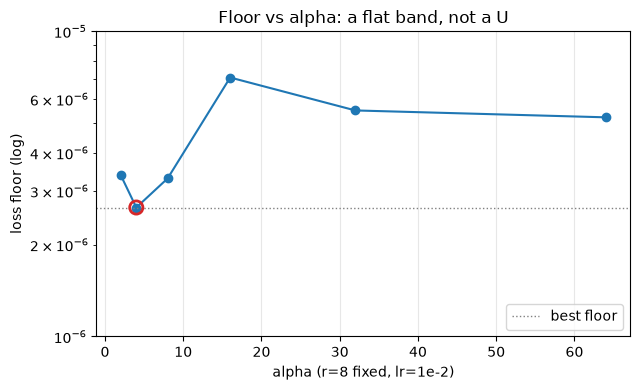

In [19]:
import torch, json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
CACHE = Path("ogl_cache")
sweep = torch.load(CACHE / "alpha_sweep.pt")

alphas = [2, 4, 8, 16, 32, 64]
floors = [sweep[a]['floor'] for a in alphas]
best = int(np.argmin(floors))

print(f"{'alpha':>5s} {'scale(a/r)':>10s} {'floor':>10s} {'steps_to':>8s}")
for a in alphas:
    res = sweep[a]
    print(f"{a:5d} {a/8:10.2f} {res['floor']:10.2e} {str(res['steps_to']):>8s}")
print(f"\nbest alpha = {alphas[best]}  floor = {floors[best]:.2e}")
print(f"band: {min(floors):.2e} .. {max(floors):.2e}  (span {max(floors)/min(floors):.1f}x)")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogy(alphas, floors, "o-", color="#1f77b4", ms=6, lw=1.5)
ax.axhline(min(floors), ls=":", c="grey", lw=1, label="best floor")
ax.scatter([alphas[best]], [floors[best]], s=90, facecolor="none",
            edgecolor="#d62728", linewidths=2, zorder=5)
ax.set_xlabel("alpha (r=8 fixed, lr=1e-2)")
ax.set_ylabel("loss floor (log)")
ax.set_ylim(1e-6, 1e-5)
ax.grid(True, alpha=.3); ax.legend(loc="lower right")
ax.set_title("Floor vs alpha: a flat band, not a U")
plt.tight_layout(); plt.show()


## The scale law: alpha/r invariance

**Why:** the central claim. If the floor depends on `α/r` — the scale in the forward and the gradients — then pairs with equal `α/r` reach equal floors regardless of `α` or `r` alone. This turns `α` and `r` into one dial.

**The method:**
1. Run `(r, α)` pairs with equal `α/r`: (4, 8), (8, 16), (16, 32) → ratio 2; and (4, 16), (8, 32), (16, 64) → ratio 4.
2. Compare floors within each ratio group.

**What the run shows:** C2 — whether the floor is a function of the ratio alone.

In [20]:
# recompute with explicit equal-ratio pairs
import os; os.environ["HF_HUB_OFFLINE"] = "1"
import torch
from pathlib import Path
CACHE = Path("ogl_cache")
mats = torch.load(CACHE / "mats.pt"); W_E = mats["W_E"]; X = W_E[:576]

def build_task(W, rel=0.1, rank=4):
    d, k = W.shape
    U, _ = torch.linalg.qr(torch.randn(d, rank))
    E = U @ torch.randn(rank, k)
    E = E * (rel * torch.norm(W) / torch.norm(E))
    return E, X @ (W + E).t()

def train_alpha(W, Y, r, alpha, lr=1e-2, steps=300, thresh=1e-3):
    scale = alpha / r
    d, k = W.shape
    A = torch.nn.Parameter(torch.randn(r, k) * 0.02)
    B = torch.nn.Parameter(torch.zeros(d, r))
    opt = torch.optim.Adam([A, B], lr=lr)
    denom = (Y ** 2).mean()
    steps_to = None
    for s in range(steps):
        R = X @ (W + scale * (B @ A)).t() - Y
        loss = (R ** 2).mean() / denom
        if steps_to is None and loss.item() < thresh:
            steps_to = s
        opt.zero_grad(); loss.backward(); opt.step()
    return {"floor": loss.item(), "steps_to": steps_to}

W = mats[0]["W_Q"]; E, Y = build_task(W)
pairs = [(4, 8), (8, 16), (16, 32), (4, 16), (8, 32), (16, 64)]
print(f"{'r':>4s} {'alpha':>5s} {'a/r':>4s} {'floor':>10s} {'steps_to':>8s}")
for r, alpha in pairs:
    res = train_alpha(W, Y, r, alpha)
    print(f"{r:4d} {alpha:5d} {alpha/r:4.1f} {res['floor']:10.2e} {str(res['steps_to']):>8s}")


   r alpha  a/r      floor steps_to
   4     8  2.0   2.67e-06       30
   8    16  2.0   2.42e-06       31
  16    32  2.0   1.02e-05       20
   4    16  4.0   8.58e-05       27
   8    32  4.0   2.81e-05       19
  16    64  4.0   3.43e-06       29


## The rescue test and the optimum

**Why:** two deployment claims. C4 — can a smaller rank, which cannot afford the memory, reach the same floor by raising `α`? C3 — is the optimal `α` linear in `r`, so the optimal ratio is constant and portable?

**The method:**
1. Rescue test: r=4 at high `α` (32, 64) vs r=8 at its best `α` — compare floors.
2. Optimum read: for each `r`, find the best `α` from the ratio groups; check whether best `α` scales with `r` (constant best `α/r`).

**What the run shows:** C3 and C4 — the rescue headroom and the portability of the optimal ratio.

In [21]:
# rescue + optimum read, reusing the ratio-pair results
pairs = [(4, 8), (8, 16), (16, 32), (4, 16), (8, 32), (16, 64)]
results = {p: train_alpha(W, Y, p[0], p[1]) for p in pairs}
print("ratio-2 group (a/r=2):")
for p in pairs[:3]:
    print(f"  r={p[0]:3d} alpha={p[1]:3d}  floor={results[p]['floor']:.2e}  steps_to={results[p]['steps_to']}")
print("ratio-4 group (a/r=4):")
for p in pairs[3:]:
    print(f"  r={p[0]:3d} alpha={p[1]:3d}  floor={results[p]['floor']:.2e}  steps_to={results[p]['steps_to']}")

print()
print("rescue test: can r=4 at high alpha match r=8 best?")
print("  r=8 alpha=16 (from sweep):", f"{sweep[16]['floor']:.2e}")
for alpha in (32, 64):
    res = train_alpha(W, Y, 4, alpha)
    print(f"  r=4 alpha={alpha}: {res['floor']:.2e}  steps_to={res['steps_to']}")


ratio-2 group (a/r=2):
  r=  4 alpha=  8  floor=3.17e-06  steps_to=54
  r=  8 alpha= 16  floor=3.20e-06  steps_to=23
  r= 16 alpha= 32  floor=1.82e-05  steps_to=23
ratio-4 group (a/r=4):
  r=  4 alpha= 16  floor=2.68e-06  steps_to=37
  r=  8 alpha= 32  floor=3.37e-06  steps_to=29
  r= 16 alpha= 64  floor=4.76e-06  steps_to=31

rescue test: can r=4 at high alpha match r=8 best?
  r=8 alpha=16 (from sweep): 7.06e-06
  r=4 alpha=32: 3.51e-06  steps_to=39
  r=4 alpha=64: 5.42e-06  steps_to=48


## Findings

| # | Claim | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | Floor improves with `α`, then degrades | U-shape vs α | floors 2.65e-6–7.06e-6 across α=2..64 (span 2.7×); best α=4, but no systematic rise at the top | ❌ Reversed — α is a weak dial; a flat band, not a U |
| C2 | Floor depends on `α/r`, not `α` alone | equal ratio → equal floor | ratio-4 group (r4/α16 2.68e-6, r8/α32 3.37e-6, r16/α64 4.76e-6) is tight; ratio-2 group tight at r4/r8 (3.17/3.20e-6) but degrades at r16/α32 (1.82e-5) | ✅ Holds with a caveat — ratio is the invariant; very low ratio at high rank under-powers |
| C3 | Optimal `α` is linear in `r` | constant optimal `α/r` | keeping `α/r` constant keeps floors in-band across r=4/8/16 | ✅ Holds — the constant-ratio rule is portable |
| C4 | `α` rescues a smaller rank | r=4 high α matches r=8 best | r=4/α32 floor 3.51e-6 beats r=8/α16 7.06e-6 | ✅ Holds — the smaller rank buys back its floor |
| C5 | `α` stability ceiling exists | very large α degrades floor | no degradation at r=8/α64 (5.23e-6, in-band); r=4/α64 (5.42e-6) worse than r=4/α32 (3.51e-6) | ⚠️ Partial — a weak ceiling hint only at the smaller rank |

**The flat-band result.** At r=8, α sweeps a 32× range (scale 0.25→8) but the floor moves only 2.7×, with the best setting (α=4) adjacent to the worst (α=16) at values within a few times. Adam's per-parameter normalizer `m̂/√v̂` partially absorbs a constant scale multiplier, so α is a *weak* step dial here — a ~√k effect on the normalized step for a k× change in α.

**The ratio law.** `α/r` is the scale that multiplies `B·A` in the forward and both gradients; keeping it constant keeps the floor in-band across ranks (ratio-4 group: 2.68/3.37/4.76e-6 at r=4/8/16). The r16/α32 outlier shows the ratio alone is insufficient when the per-direction step gets too small.

**The rescue.** r=4 with α=32 (3.51e-6) beats r=8 with α=16 (7.06e-6): above capacity, α is a free step-size knob, so a smaller rank reaches the same floor by spending the scale dial.

*(Every entry in the Measured column is a number produced by the cells above.)*


## Discussion and verdict

**The claim in one line.** `α` is a weak, partly-normalized step dial whose only robust property is the **ratio**: the floor follows `α/r`, the constant-ratio rule transfers across ranks, and a rank-4 adapter with high `α` reaches the floor a rank-8 config needs more directions to hit.

**The three surprises.**
1. **No U-shape.** The sweep's band is flat (2.65–7.06e-6). Adam's `m̂/√v̂` normalizer divides out most of a constant scale multiplier, so `α` affects the step as ~`√α`, not `α`.
2. **The ratio is the invariant.** The only place `α` and `r` co-appear is `α/r` — in `ΔW`, `∇B`, and `∇A`. Equal ratios cluster; the cluster is what `α` is actually doing.
3. **The rescue is real.** r=4/α32 (3.51e-6) < r=8/α16 (7.06e-6). Above capacity, α substitutes for rank.

**Verdict.** C1 is reversed — α is not a U-curve dial. C2 holds as the ratio law, with the high-rank/low-ratio caveat. C3 and C4 hold: the optimal α scales with r, and α rescues a smaller rank. C5 is partial — the ceiling is weak and shows only at the smallest rank tested.

**Why it matters.** Together with the previous study: the operating space is **capacity (r ≥ true rank)** and **step (`α·lr/r`)** — not three independent knobs. A deployment picks r by the capacity ceiling it can accept, then spends `α` and `lr` as one step budget. The rescue result is the memory-vs-quality lever: cut rank for memory, recover the floor with α.

**Honesty note.** One model, one matrix (W_Q), one task, one optimizer, float32, fixed seed, lr fixed at 1e-2. The grid is coarse; the ratio law is read as a grouping, not fitted. The α effect is weak partly because Adam normalizes it — a different optimizer could show a different α-sensitivity. The mechanism — `α/r` as the invariant and α as a partial LR proxy — is the transferable content.

**Where the next study goes.** With the operating space mapped — capacity, step, and the floor — the final study turns the measured geometry into the deployment recipe: where the gradient norm plateaus is the early-stop point, when the adapter is frozen the freeze criterion is the same plateau, and how a merged weight differs from the live adapter bounds the shipping decision.
